<a href="https://colab.research.google.com/github/Shravankarthik2007/time-series-analysis-of-three-stock/blob/main/time_series_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_2032/3778156730.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df["Close"].resample("M").mean()


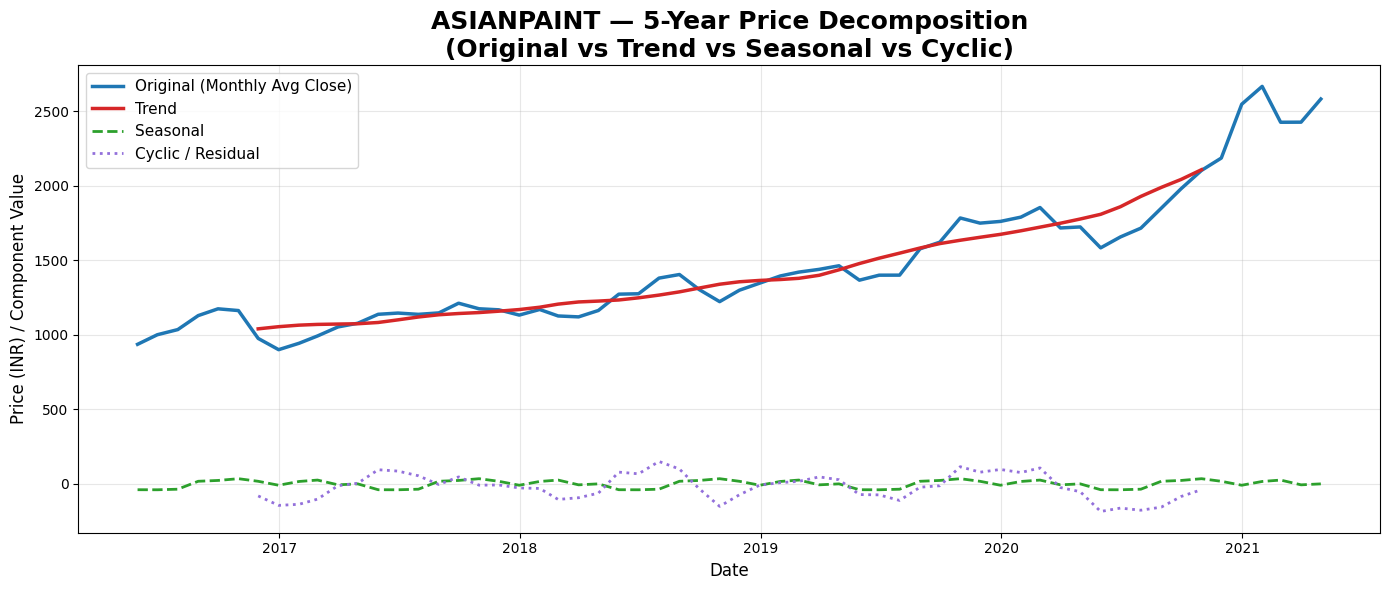

/tmp/ipykernel_2032/3778156730.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df["Close"].resample("M").mean()


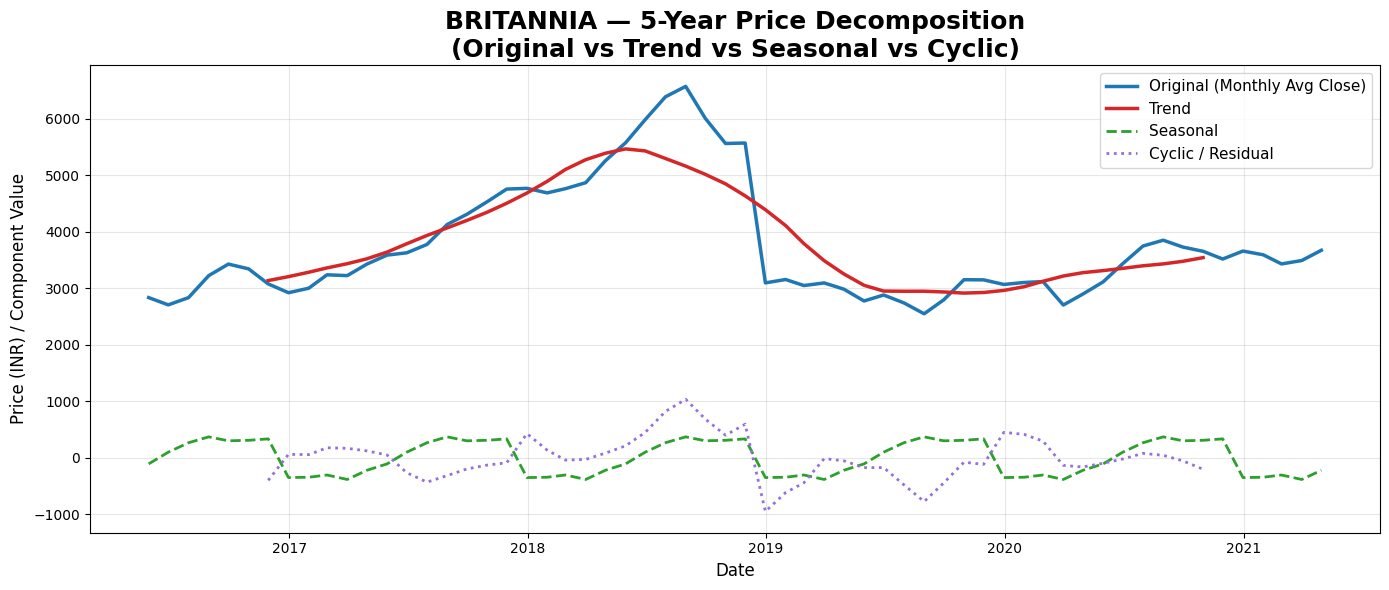

/tmp/ipykernel_2032/3778156730.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df["Close"].resample("M").mean()


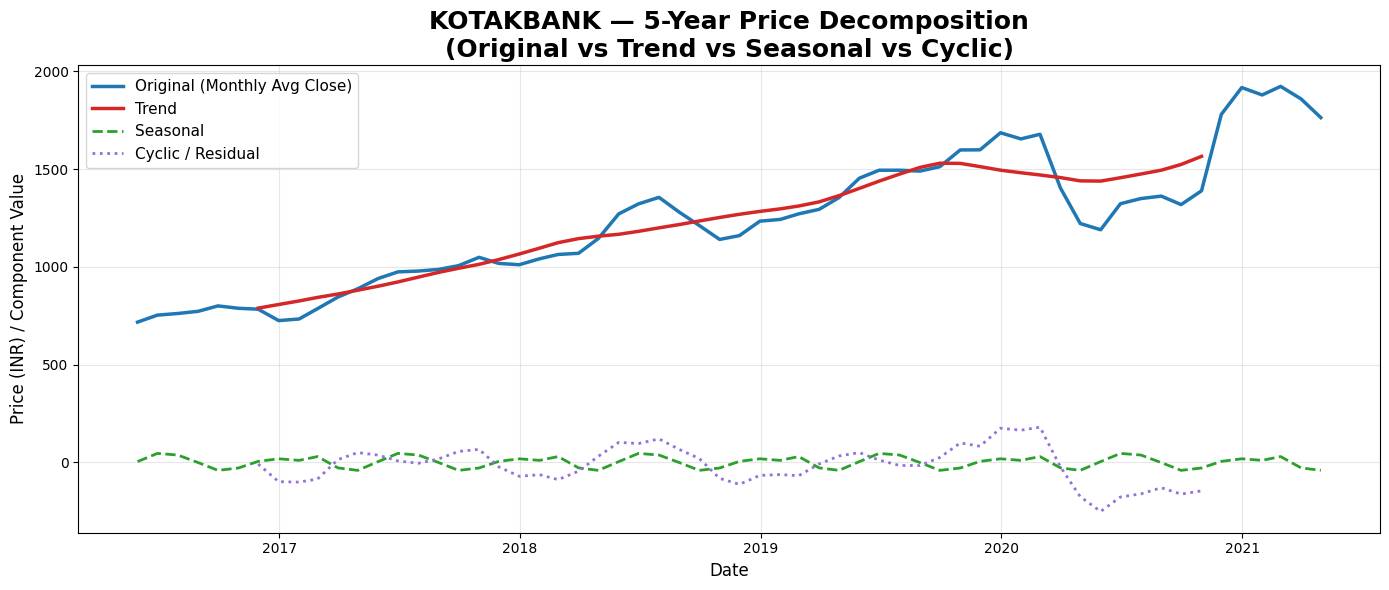

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

datasets = {
    "ASIANPAINT": "ASIANPAINT.csv",
    "BRITANNIA": "BRITANNIA.csv",
    "KOTAKBANK": "KOTAKBANK.csv"
}

for company, file in datasets.items():

    df = pd.read_csv(file)

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date")
    df.set_index("Date", inplace=True)

    df = df[df.index >= (df.index.max() - pd.DateOffset(years=5))]

    monthly = df["Close"].resample("M").mean()

    result = seasonal_decompose(monthly, model="additive", period=12)

    plt.figure(figsize=(14,6))

    plt.plot(
        monthly.index,
        monthly,
        color="#1f77b4",
        linewidth=2.5,
        label="Original (Monthly Avg Close)"
    )

    plt.plot(
        result.trend.index,
        result.trend,
        color="#d62728",
        linewidth=2.5,
        label="Trend"
    )

    plt.plot(
        result.seasonal.index,
        result.seasonal,
        color="#2ca02c",
        linestyle="--",
        linewidth=2,
        label="Seasonal"
    )

    plt.plot(
        result.resid.index,
        result.resid,
        color="mediumpurple",
        linestyle=":",
        linewidth=2,
        label="Cyclic / Residual"
    )

    plt.title(
        f"{company} — 5-Year Price Decomposition\n(Original vs Trend vs Seasonal vs Cyclic)",
        fontsize=18,
        weight="bold"
    )

    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Price (INR) / Component Value", fontsize=12)

    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

As you can see, plotting all components on a single graph makes it difficult to discern the details of the seasonal and residual components due to their much smaller scale compared to the original and trend components. For a clearer view of each individual component, the previous multi-subplot decomposition plot is generally preferred.